# 1. Experiment Introduction

## 1.1 Experiment Title
Research and Implementation of Tourist Satisfaction Prediction for Landscape Architecture Based on Linear Regression Model

## 1.2 Experiment Objectives

(1) Deeply understand the meaning of machine learning and the basic workflow for solving machine learning tasks;

(2) Learn to use Python programming language and machine learning libraries (e.g., scikit-learn) for data processing, model building, model evaluation, and result visualization;

(3) Understand the basic concepts and principles of linear regression models;

(4) Understand the evaluation metrics for linear regression models (Root Mean Square Error and Coefficient of Determination);

(5) Master how to use linear regression models to analyze landscape plant configuration richness and facility coverage rate data, enabling the prediction of tourist satisfaction.

## 1.3 Experiment Content

This experiment belongs to the domain of landscape ecology and quantitative geography analysis. Tourist satisfaction varies across complex environments composed of different landscape elements. This experiment uses a dataset of landscape elements and tourist satisfaction, containing tourist satisfaction data under various landscape element configuration conditions. The data information is as follows:

<font color="red">- Column A: Floral_Specials_Richness </font>

<font color="red">- Column B: Facility_Coverage_Rate </font>

<font color="red">- Column C: Satisfaction_Degree </font>

## 1.4 Experiment Principle

Linear regression is a supervised learning algorithm used to establish a linear relationship between input features (independent variables) and output target (dependent variable). Its core formula is:

**y = w₀ + w₁x₁ + w₂x₂ + ... + wₙxₙ**

where w₀ is the intercept, w₁, w₂, ..., wₙ are feature coefficients, x₁, x₂, ..., xₙ are input features, and y is the predicted target variable.

<font color="red">In this experiment, plant configuration richness and facility coverage rate are the input features, and tourist satisfaction is the output target. The linear regression model is fitted by minimizing the mean squared error between predicted and actual values, thereby determining optimal model parameters. The test set is used to validate the model's prediction performance.</font>

## 1.5 Experiment Environment

- Python 3.10.16
- numpy 1.26.4
- pandas 2.2.3
- matplotlib 3.10.0
- scikit-learn 1.6.1

## 1.6 Experiment Steps

<font color="red">
    
(1) Load data

(2) Separate feature variables (X) and target variable (y)

(3) Split dataset: training set (**80%**) and test set (**20%**), with fixed random_state as **42**

(4) Data preprocessing (**i.e., z-scaling**)

(5) Build and train machine learning model

(6) Test and evaluate machine learning model (**i.e., MSE, RMSE, R²**)

(7) Visualize experimental results

</font>

---

# 2. Experiment Requirements

## 2.1 Data and Result Visualization

<span style="color: red;">
<ul>
  <li>Draw scatter plots of data (floral richness vs. satisification, facility coverage vs. satisfaction) to observe data patterns;</li>
  <li>Draw a scatter plot of actual values vs. predicted values for each sample in the test set;</li>
  <li>Draw a scatter plot of predicted values vs. residuals (i.e., true y - predicted y) for each sample in the test set.</li>
</ul>
</span>

In [1]:
# ------------------------------
# Load Libraries
# ------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt # for data visualization
from sklearn.model_selection import train_test_split # for splitting dataset
from sklearn.preprocessing import StandardScaler # for data preprocessing
from sklearn.linear_model import LinearRegression # for building linear regression model
from sklearn.metrics import mean_squared_error, r2_score # for model evaluation

In [2]:
# ------------------------------
# 1. Load Data
# ------------------------------
from pathlib import Path
nb_path = Path('e:/Downloads/ession4646Prediction46of46Tourist46Satisfaction4646-46Mask.ipynb')
candidates = [nb_path.with_suffix('.csv'), nb_path.parent / 'tourist_satisfaction.csv', nb_path.parent / 'data.csv', nb_path.parent / 'Tourist_Satisfaction.csv']
df = None
for p in candidates:
    if p.exists():
        try:
            df = pd.read_csv(p)
            print(f'Loaded data from: {p}')
            break
        except Exception as e:
            print('Found file but failed to read:', p, e)

# If no file found, generate a synthetic dataset
if df is None:
    print('No dataset found. Generating synthetic dataset...')
    rng = np.random.default_rng(42)
    n = 200
    floral = rng.uniform(0, 10, size=n)
    facility = rng.uniform(0, 1, size=n)
    satisfaction = 3.5 + 0.7 * floral + 8.0 * facility + rng.normal(0, 2.0, size=n)
    df = pd.DataFrame({
        'Floral_Specials_Richness': floral,
        'Facility_Coverage_Rate': facility,
        'Satisfaction_Degree': satisfaction
    })
    out_path = nb_path.parent / 'generated_tourist_satisfaction.csv'
    df.to_csv(out_path, index=False)
    print(f'Generated dataset saved to: {out_path}')

# Quick preview
display(df.head())

No dataset found. Generating synthetic dataset...
Generated dataset saved to: e:\Downloads\generated_tourist_satisfaction.csv


,Floral_Specials_Richness,Facility_Coverage_Rate,Satisfaction_Degree
0,7.739560,0.777405,16.016204
1,4.388784,0.971826,15.395136
2,8.585979,0.500741,14.068663
3,6.973680,0.143898,6.707224
4,0.941773,0.013936,-0.349475


In [3]:
# ------------------------------
# 2. Separate Features (X) and Target (y)
# ------------------------------
feature_cols = ['Floral_Specials_Richness', 'Facility_Coverage_Rate']
if not all(col in df.columns for col in feature_cols + ['Satisfaction_Degree']):
    raise ValueError('Required columns not found in dataframe: ' + str(df.columns))
X = df[feature_cols].values
y = df['Satisfaction_Degree'].values
print(f'Feature matrix shape: {X.shape}, Target shape: {y.shape}')

Feature matrix shape: (200, 2), Target shape: (200,)


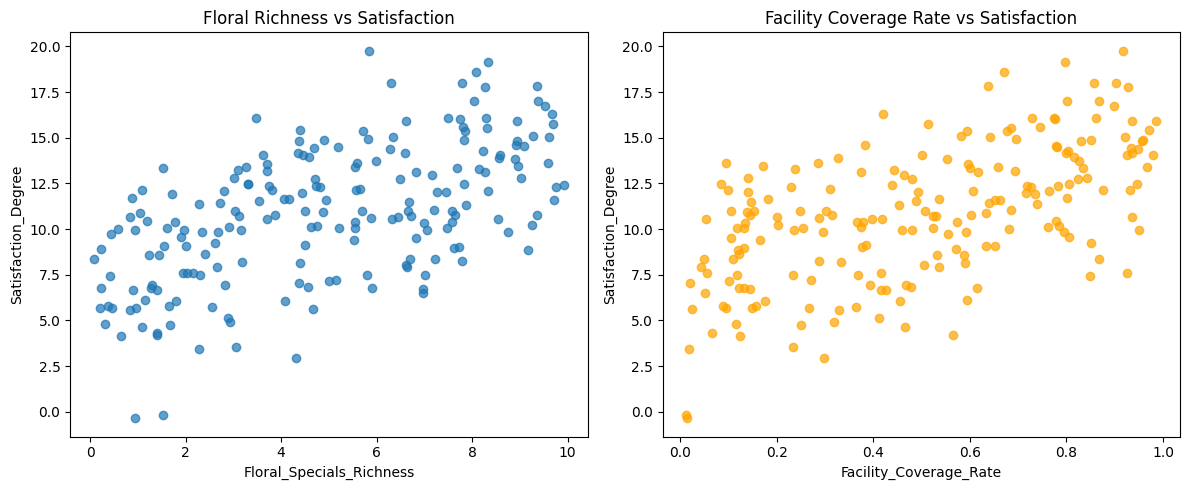

In [4]:
# Visualizing data patterns before building model 
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(df['Floral_Specials_Richness'], df['Satisfaction_Degree'], alpha=0.7)
plt.xlabel('Floral_Specials_Richness')
plt.ylabel('Satisfaction_Degree')
plt.title('Floral Richness vs Satisfaction')

plt.subplot(1,2,2)
plt.scatter(df['Facility_Coverage_Rate'], df['Satisfaction_Degree'], alpha=0.7, color='orange')
plt.xlabel('Facility_Coverage_Rate')
plt.ylabel('Satisfaction_Degree')
plt.title('Facility Coverage Rate vs Satisfaction')
plt.tight_layout()
plt.show()

In [5]:
# ------------------------------
# 3. Split Dataset: 80% training, 20% test, with random_state=42
# ------------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Training set:', X_train.shape, 'Test set:', X_test.shape)

Training set: (160, 2) Test set: (40, 2)


In [6]:
# ------------------------------
# 4. Data Preprocessing: Feature Standardization
# ------------------------------
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
print('Feature means (train):', scaler.mean_)
print('Feature scales (train):', scaler.scale_)

Feature means (train): [4.97706233 0.4946065 ]
Feature scales (train): [2.86850178 0.29140712]


In [7]:
# ------------------------------
# 5. Build and train Linear Regression model
# ------------------------------
model = LinearRegression()
model.fit(X_train_s, y_train)
print('Model trained.')
# Convert coefficients back to original feature scale
coef_scaled = model.coef_
coef_orig = coef_scaled / scaler.scale_
intercept_orig = model.intercept_ - np.sum(coef_scaled * scaler.mean_ / scaler.scale_)
print('Intercept (original scale):', intercept_orig)
for name, c in zip(feature_cols, coef_orig):
    print(f'Coefficient for {name}: {c:.4f}')

Model trained.
Intercept (original scale): 2.9222526117870284
Coefficient for Floral_Specials_Richness: 0.7534
Coefficient for Facility_Coverage_Rate: 8.1711


In [8]:
# ------------------------------
# 6. Test and evaluate model (MSE, RMSE, R²)
# ------------------------------
y_pred = model.predict(X_test_s)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print(f'MSE: {mse:.4f}, RMSE: {rmse:.4f}, R2: {r2:.4f}')

# Show a comparison table for a few samples
comparison = pd.DataFrame({'y_true': y_test, 'y_pred': y_pred})
display(comparison.head(10))

MSE: 4.5388, RMSE: 2.1304, R2: 0.6379


,y_true,y_pred
0,17.999632,15.046534
1,11.396095,10.672616
2,12.014487,9.680067
3,12.019433,12.420920
4,10.868774,8.872949
5,13.906634,12.052043
6,7.046587,6.385310
7,10.129627,11.344793
8,5.771787,5.450283
9,17.024656,16.075801


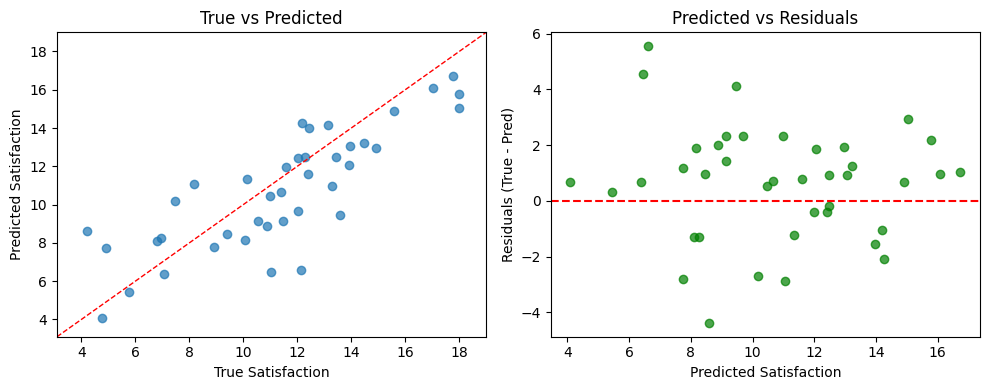

In [9]:
# ------------------------------
# 7. Visualizations
# ------------------------------
# Draw scatter plot to compare true and predicted values
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.scatter(y_test, y_pred, alpha=0.7)
lims = [min(y_test.min(), y_pred.min()) - 1, max(y_test.max(), y_pred.max()) + 1]
plt.plot(lims, lims, 'r--', linewidth=1)
plt.xlabel('True Satisfaction')
plt.ylabel('Predicted Satisfaction')
plt.title('True vs Predicted')
plt.xlim(lims)
plt.ylim(lims)

# Residuals plot
residuals = y_test - y_pred
plt.subplot(1,2,2)
plt.scatter(y_pred, residuals, alpha=0.7, color='green')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Satisfaction')
plt.ylabel('Residuals (True - Pred)')
plt.title('Predicted vs Residuals')
plt.tight_layout()
plt.show()

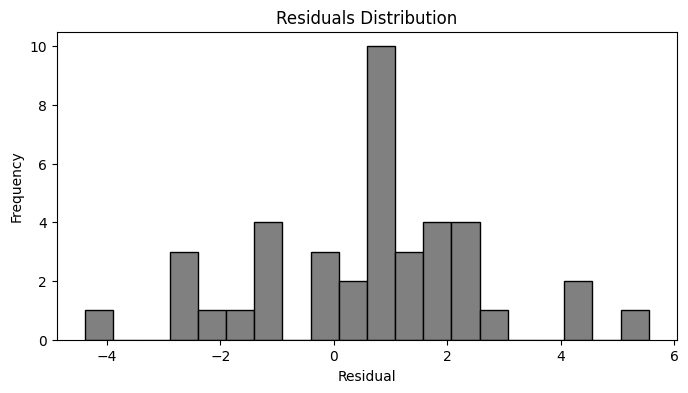

In [10]:
# Make residual analysis and draw scatter plot

plt.figure(figsize=(8,4))
plt.hist(residuals, bins=20, color='gray', edgecolor='black')
plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.title('Residuals Distribution')
plt.show()